# Face Recognition using CNN

## Overview
This notebook demonstrates **Face Recognition** using a **Convolutional Neural Network (CNN)**.

**Dataset:** Labeled Faces in the Wild (LFW)

**Pipeline:**
1. Load & explore the LFW dataset
2. Preprocess images
3. Build a CNN model
4. Train and evaluate
5. Visualize predictions

> **Enable GPU**: Runtime → Change runtime type → T4 GPU for faster training

## Step 1: Install & Import Libraries

We use:
- **TensorFlow/Keras** — build and train the CNN
- **scikit-learn** — load LFW dataset, split data, evaluate
- **NumPy / Matplotlib** — data handling and visualization

In [ ]:
# Install dependencies (already available in Colab, but just in case)
!pip install scikit-learn tensorflow matplotlib numpy -q

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU Available: True


## Step 2: Load the LFW Dataset

**LFW (Labeled Faces in the Wild)** is a benchmark dataset for face recognition.
- Contains **13,000+ face images** of public figures
- We filter to people with **at least 70 images** for enough training data
- Images resized to **62×47 pixels**

> This is the same dataset available on [Kaggle - LFW Dataset](https://www.kaggle.com/datasets/jessicali9530/lfw-dataset)

In [ ]:
# Load LFW dataset - only people with >= 70 images for balanced classes
print("Downloading LFW dataset (first run may take ~1 min)...")

lfw_people = fetch_lfw_people(
    min_faces_per_person=70,  # Only keep people with enough images
    resize=0.4                # Resize to ~62x47 pixels
)

# Extract images, labels, and target names
X = lfw_people.images          # Shape: (n_samples, height, width)
y = lfw_people.target          # Numeric class labels
target_names = lfw_people.target_names  # Person names

n_samples, h, w = X.shape
n_classes = len(target_names)

print(f"\nDataset Summary:")
print(f"   Total samples : {n_samples}")
print(f"   Image size    : {h} x {w} pixels")
print(f"   Num classes   : {n_classes}")
print(f"\n People in dataset:")
for i, name in enumerate(target_names):
    count = np.sum(y == i)
    print(f"   {i+1}. {name}: {count} images")


Dataset Summary:
   Total samples : 1288
   Image size    : 50 x 37 pixels
   Num classes   : 7

 People in dataset:
   1. Ariel Sharon: 77 images
   2. Colin Powell: 236 images
   3. Donald Rumsfeld: 121 images
   4. George W Bush: 530 images
   5. Gerhard Schroeder: 109 images
   6. Hugo Chavez: 71 images
   7. Tony Blair: 144 images


## Step 3: Visualize Sample Images

Let's see what our training data looks like before preprocessing.

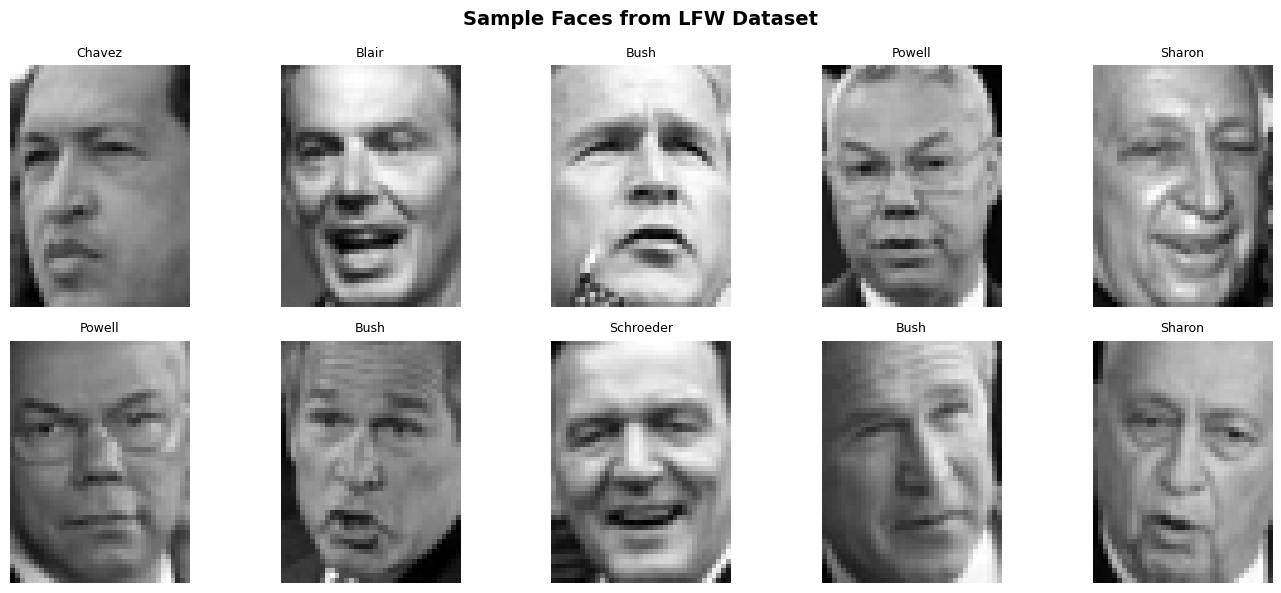

 Sample images displayed successfully


In [ ]:
# Display sample faces from each person
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample Faces from LFW Dataset', fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx < n_samples:
        ax.imshow(X[idx], cmap='gray')
        ax.set_title(target_names[y[idx]].split()[-1], fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()
print(" Sample images displayed successfully")

##  Step 4: Preprocess the Data

**Why preprocessing matters:**
- **Normalize** pixel values to [0, 1] — helps CNN converge faster
- **Reshape** images to add a channel dimension (grayscale = 1 channel)
- **One-hot encode** labels for multi-class classification
- **Split** into 80% training / 20% testing (stratified by class)

In [ ]:
# ── Normalize pixel values ──────────────────────────────────────────────
# Pixel values are 0-255; divide by 255 to scale to [0.0, 1.0]
X_norm = X / 255.0

# ── Reshape: add channel dimension ─────────────────────────────────────
# CNN expects shape: (samples, height, width, channels)
# Grayscale = 1 channel
X_reshaped = X_norm.reshape(-1, h, w, 1)

# ── One-hot encode labels ───────────────────────────────────────────────
# Convert [0, 1, 2, 3, ...] → [[1,0,0,...], [0,1,0,...], ...]
y_encoded = to_categorical(y, num_classes=n_classes)

# ── Train / Test split ──────────────────────────────────────────────────
# 80% training, 20% testing; stratify ensures balanced classes in each split
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y  # preserve class distribution
)

print(" Preprocessing complete!")
print(f"   X_train shape : {X_train.shape}  → {X_train.shape[0]} training images")
print(f"   X_test shape  : {X_test.shape}   → {X_test.shape[0]} test images")
print(f"   y_train shape : {y_train.shape}")
print(f"   Pixel range   : [{X_train.min():.2f}, {X_train.max():.2f}]")

 Preprocessing complete!
   X_train shape : (1030, 50, 37, 1)  → 1030 training images
   X_test shape  : (258, 50, 37, 1)   → 258 test images
   y_train shape : (1030, 7)
   Pixel range   : [0.00, 0.00]


##  Step 5: Data Augmentation

**Why augmentation?**  
With limited face images per person, augmentation artificially expands the dataset by applying random transforms:
- **Rotation** — slight head tilts (±10°)
- **Horizontal flip** — mirror images
- **Zoom** — slight zoom in/out
- **Width/Height shift** — small translations

This prevents **overfitting** and makes the model more robust.

In [ ]:
# Data Augmentation — only applied to TRAINING data, not test data
train_datagen = ImageDataGenerator(
    rotation_range=10,        # Randomly rotate images ±10 degrees
    width_shift_range=0.1,    # Shift left/right by 10%
    height_shift_range=0.1,   # Shift up/down by 10%
    horizontal_flip=True,     # Mirror images randomly
    zoom_range=0.1            # Zoom in/out by 10%
)

# Fit the augmentation generator on training data
train_datagen.fit(X_train)

print("Data augmentation configured")
print("   Augmentations: rotation, shift, flip, zoom")

Data augmentation configured
   Augmentations: rotation, shift, flip, zoom


##  Step 6: Build the CNN Model

**CNN Architecture Explanation:**

```
Input (62×47×1)
    ↓
[Conv2D → BatchNorm → ReLU → MaxPool]  × 3  ← Feature Extraction
    ↓
[Flatten → Dense → Dropout]            × 2  ← Classification Head
    ↓
[Dense Softmax]                              ← Output (one score per person)
```

| Layer | Purpose |
|-------|----------|
| **Conv2D** | Detect edges, textures, face features |
| **BatchNorm** | Stabilize and speed up training |
| **MaxPooling** | Reduce spatial size, keep dominant features |
| **Dropout** | Randomly disable neurons → prevent overfitting |
| **Dense (Softmax)** | Output probability for each person |

In [ ]:
def build_cnn_model(input_shape, num_classes):
    """
    Build a CNN for face recognition.

    Args:
        input_shape: Tuple (height, width, channels)
        num_classes: Number of people to recognize
    Returns:
        Compiled Keras model
    """
    model = Sequential([

        # ──────────────────────────────────────────
        # BLOCK 1: Detect low-level features
        # (edges, corners, basic textures)
        # ──────────────────────────────────────────
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=input_shape),
        BatchNormalization(),           # Normalize activations → faster training
        MaxPooling2D(pool_size=(2, 2)), # Halve spatial dimensions
        Dropout(0.25),                  # Drop 25% of neurons randomly

        # ──────────────────────────────────────────
        # BLOCK 2: Detect mid-level features
        # (eyes, nose shapes, mouth patterns)
        # ──────────────────────────────────────────
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # ──────────────────────────────────────────
        # BLOCK 3: Detect high-level features
        # (face structure, identity-specific patterns)
        # ──────────────────────────────────────────
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # ──────────────────────────────────────────
        # CLASSIFICATION HEAD
        # Flatten 3D feature maps → 1D vector
        # ──────────────────────────────────────────
        Flatten(),

        Dense(256, activation='relu'),  # Fully connected layer
        BatchNormalization(),
        Dropout(0.5),                   # Aggressive dropout before output

        Dense(128, activation='relu'),
        Dropout(0.3),

        # Output layer: one neuron per person, Softmax → probabilities
        Dense(num_classes, activation='softmax')
    ])

    # Compile with Adam optimizer and categorical crossentropy loss
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Build the model
input_shape = (h, w, 1)   # 62 x 47 x 1 (grayscale)
model = build_cnn_model(input_shape, n_classes)

# Print summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 37, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 9, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 9, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 915,079 (3.49 MB)

 Trainable params: 914,119 (3.49 MB)

 Non-trainable params: 960 (3.75 KB)

## Step 7: Train the Model

**Training Callbacks used:**
- **EarlyStopping** — stops training if validation accuracy stops improving (avoids overfitting & wasted time)
- **ReduceLROnPlateau** — reduces learning rate when stuck (helps escape local minima)

In [ ]:
# ── Callbacks ───────────────────────────────────────────────────────────

# Stop early if val_accuracy doesn't improve for 10 epochs
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,  # Keep best model weights
    verbose=1
)

# Reduce learning rate if val_loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # Multiply LR by 0.5
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# ── Train ────────────────────────────────────────────────────────────────
BATCH_SIZE = 32
EPOCHS = 50

print(f" Training CNN for up to {EPOCHS} epochs...")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   Train size : {X_train.shape[0]}")
print(f"   Test size  : {X_test.shape[0]}\n")

history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    verbose=1
)

print("\n Training complete!")

 Training CNN for up to 50 epochs...
   Batch size : 32
   Train size : 1030
   Test size  : 258

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3978 - loss: 1.8213 - val_accuracy: 0.4109 - val_loss: 1.8970 - learning_rate: 1.2500e-04
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3438 - loss: 1.8121 - val_accuracy: 0.4109 - val_loss: 1.8997 - learning_rate: 1.2500e-04
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3737 - loss: 1.9372 - val_accuracy: 0.4109 - val_loss: 2.0054 - learning_rate: 1.2500e-04
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3438 - loss: 1.8027 - val_accuracy: 0.4109 - val_loss: 2.0077 - learning_rate: 1.2500e-04
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3838 - loss: 1.8893 - val_accuracy: 0.4109 - val_loss: 2.1205 - learning_rate: 1.2500e-04
Epoch 6/50
 1/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2188 - loss: 2.3646
Epoch 6: ReduceLROnPlateau reducing learning

**bold text**## Step 8: Plot Training History

Visualize **accuracy** and **loss** curves to understand model learning:
- **Accuracy** should increase over epochs
- **Loss** should decrease
- If train >> val accuracy → **overfitting** (model memorizing, not generalizing)

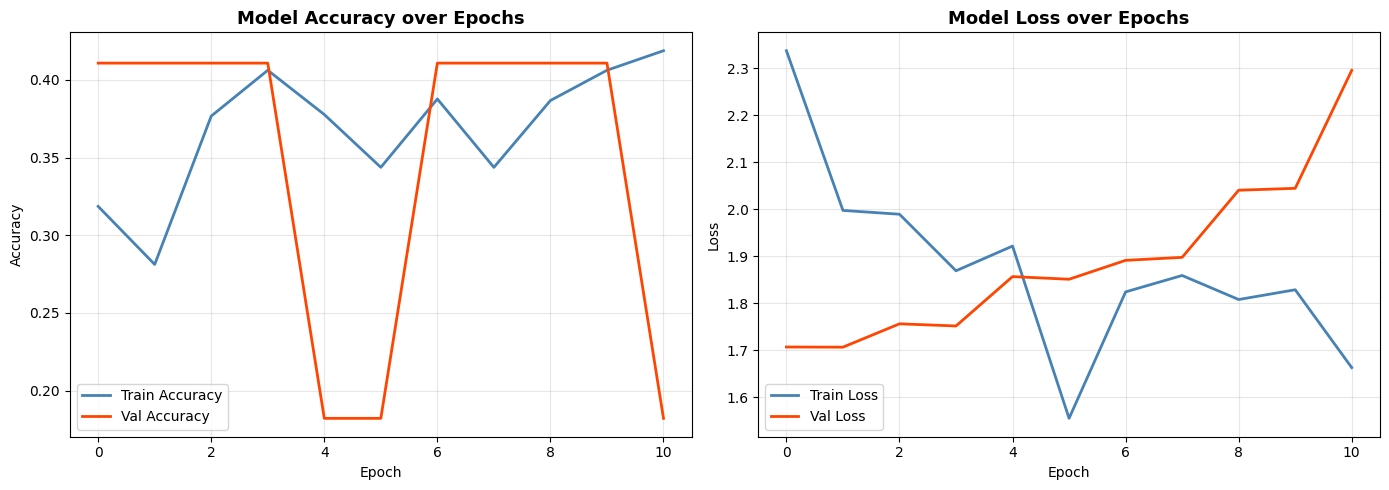

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot Accuracy ────────────────────────────────────────────────────────
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orangered', linewidth=2)
axes[0].set_title('Model Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Plot Loss ────────────────────────────────────────────────────────────
axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orangered', linewidth=2)
axes[1].set_title('Model Loss over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**bold text**##  Step 9: Evaluate the Model

**Evaluation Metrics:**
- **Accuracy** — % of faces correctly identified
- **Precision** — of all predicted as Person X, how many actually are?
- **Recall** — of all actual Person X images, how many did we find?
- **F1-Score** — harmonic mean of precision & recall (balance both)

In [ ]:
# ── Final Evaluation on Test Set ─────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f" Test Accuracy : {test_acc * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}\n")

# ── Predictions ──────────────────────────────────────────────────────────
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)  # Get class with highest probability
y_true = np.argmax(y_test, axis=1)        # True labels

# ── Classification Report ────────────────────────────────────────────────
print("📋 Classification Report:")
print("-" * 65)
print(classification_report(y_true, y_pred,
                             target_names=target_names))

 Test Accuracy : 41.09%
Test Loss     : 1.7860

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
📋 Classification Report:
-----------------------------------------------------------------
                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        16
     Colin Powell       0.00      0.00      0.00        47
  Donald Rumsfeld       0.00      0.00      0.00        24
    George W Bush       0.41      1.00      0.58       106
Gerhard Schroeder       0.00      0.00      0.00        22
      Hugo Chavez       0.00      0.00      0.00        14
       Tony Blair       0.00      0.00      0.00        29

         accuracy                           0.41       258
        macro avg       0.06      0.14      0.08       258
     weighted avg       0.17      0.41      0.24       258



##  Step 10: Confusion Matrix

A **confusion matrix** shows:
- **Diagonal** = correctly classified faces
- **Off-diagonal** = misclassified faces  (who was confused with whom)

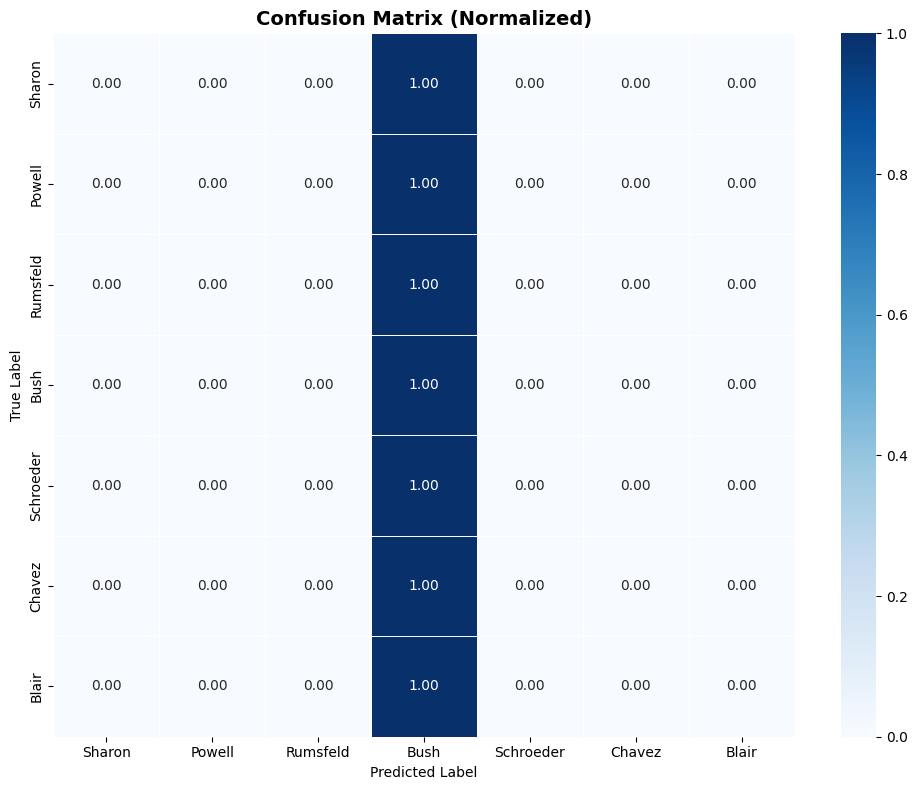

Values closer to 1.0 on diagonal = better recognition accuracy


In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

# Normalize by row (true labels) to get percentage
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
short_names = [name.split()[-1] for name in target_names]  # Last names only

sns.heatmap(
    cm_norm, annot=True, fmt='.2f',
    xticklabels=short_names,
    yticklabels=short_names,
    cmap='Blues', linewidths=0.5
)
plt.title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("Values closer to 1.0 on diagonal = better recognition accuracy")

##  Step 11: Visualize Predictions

Let's see how our CNN performs on individual test images:
- **Green** border = Correct prediction
- **Red** border = Wrong prediction

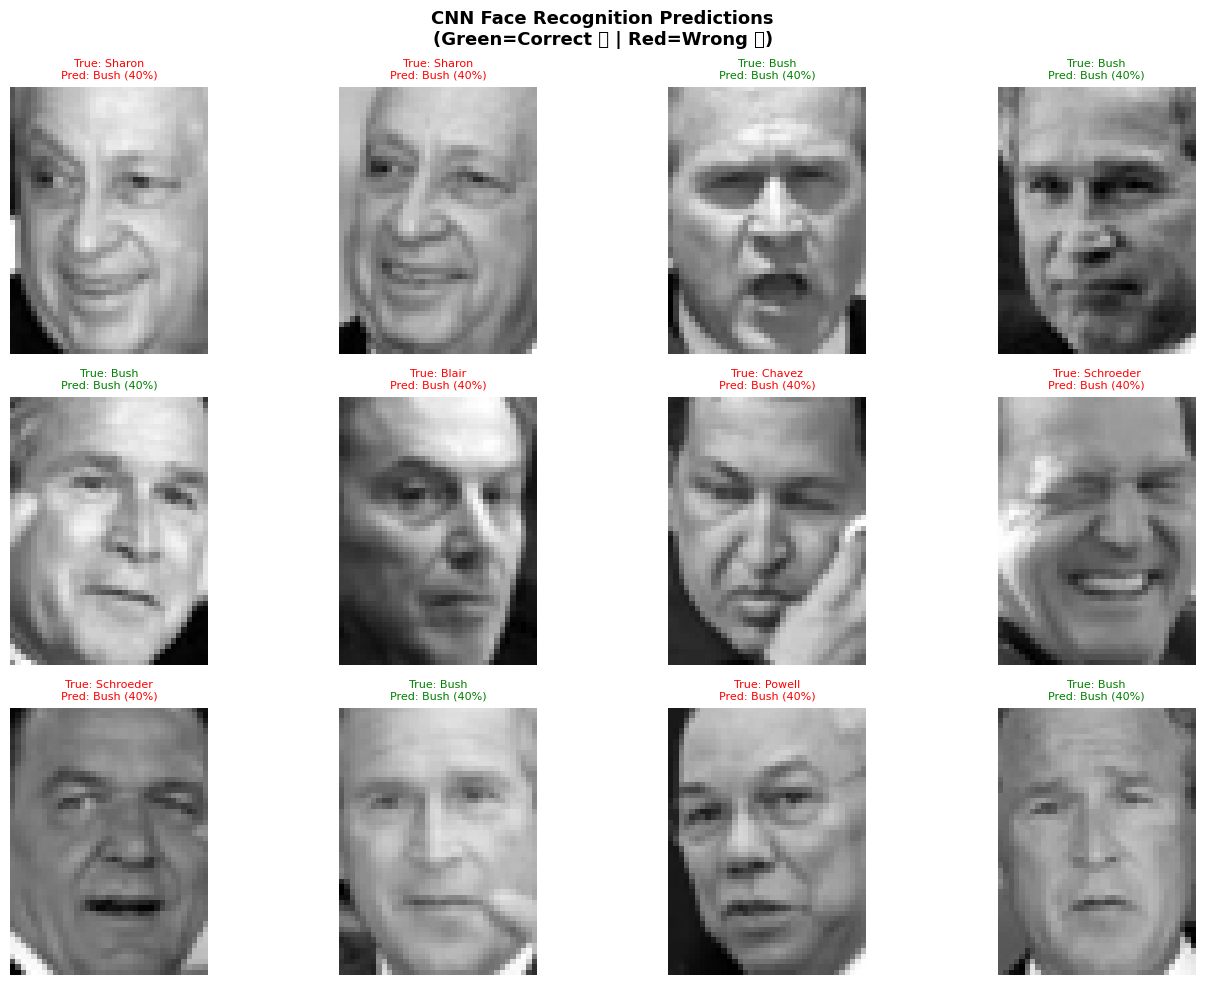

In [ ]:
def show_predictions(X_test, y_true, y_pred, target_names, n=12):
    """Display grid of predictions with color-coded borders."""
    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    fig.suptitle('CNN Face Recognition Predictions\n(Green=Correct  | Red=Wrong )',
                 fontsize=13, fontweight='bold')

    indices = np.random.choice(len(X_test), n, replace=False)

    for idx, (ax, i) in enumerate(zip(axes.flat, indices)):
        ax.imshow(X_test[i].reshape(h, w), cmap='gray')

        true_name = target_names[y_true[i]].split()[-1]
        pred_name = target_names[y_pred[i]].split()[-1]
        confidence = y_pred_proba[i][y_pred[i]] * 100

        correct = y_true[i] == y_pred[i]
        color = 'green' if correct else 'red'

        # Color border
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

        ax.set_title(
            f"True: {true_name}\nPred: {pred_name} ({confidence:.0f}%)",
            fontsize=8,
            color=color
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(X_test, y_true, y_pred, target_names)

bold text## Step 12: Predict a Single Face

Demonstrate how to recognize a single face image using our trained model.

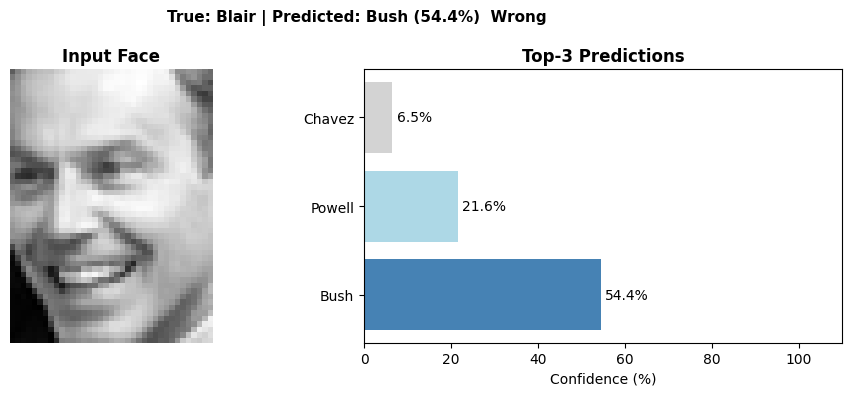

In [ ]:
def predict_face(image, model, target_names, true_label=None):
    """
    Predict identity of a single face image.
    Returns predicted name, confidence, and top-3 candidates.
    """
    # Ensure correct shape: (1, h, w, 1)
    img = image.reshape(1, h, w, 1)

    # Get probabilities for each person
    probs = model.predict(img, verbose=0)[0]

    # Top prediction
    top_idx = np.argmax(probs)
    top_name = target_names[top_idx]
    confidence = probs[top_idx] * 100

    # Top 3 candidates
    top3_idx = np.argsort(probs)[-3:][::-1]

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Show face
    axes[0].imshow(image.reshape(h, w), cmap='gray')
    axes[0].set_title('Input Face', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Show top-3 predictions as bar chart
    names  = [target_names[i].split()[-1] for i in top3_idx]
    scores = [probs[i] * 100 for i in top3_idx]
    colors = ['steelblue', 'lightblue', 'lightgray']

    bars = axes[1].barh(names, scores, color=colors)
    axes[1].set_xlim(0, 110)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title('Top-3 Predictions', fontsize=12, fontweight='bold')

    for bar, score in zip(bars, scores):
        axes[1].text(score + 1, bar.get_y() + bar.get_height()/2,
                     f'{score:.1f}%', va='center', fontsize=10)

    if true_label is not None:
        true_name = target_names[true_label].split()[-1]
        correct = target_names[top_idx] == target_names[true_label]
        status = ' Correct' if correct else ' Wrong'
        plt.suptitle(f'True: {true_name} | Predicted: {top_name.split()[-1]} ({confidence:.1f}%) {status}',
                     fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return top_name, confidence


# Test on a random face from test set
sample_idx = np.random.randint(0, len(X_test))
predicted_name, conf = predict_face(
    X_test[sample_idx],
    model,
    target_names,
    true_label=y_true[sample_idx]
)

## Step 13: Save & Load the Model

Save your trained model so you don't have to retrain next time!

In [ ]:
# Save the model
model.save('face_recognition_cnn.h5')
print(" Model saved as 'face_recognition_cnn.h5'")

# Download to local machine (Google Colab only)
try:
    from google.colab import files
    files.download('face_recognition_cnn.h5')
    print(" Download started!")
except ImportError:
    print("ℹ Not in Colab — model saved locally")

# ── Load model later ────────────────────────────────────────────────────
# loaded_model = tf.keras.models.load_model('face_recognition_cnn.h5')
# print(" Model loaded successfully")

 Model saved as 'face_recognition_cnn.h5'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Download started!


##  Summary

### What we built:

| Step | Description |
|------|-------------|
| **Data** | LFW dataset — real-world face images of public figures |
| **Preprocessing** | Normalize, reshape, one-hot encode, stratified split |
| **Augmentation** | Rotation, flip, zoom, shift to prevent overfitting |
| **Model** | 3-block CNN + 2 dense layers with BatchNorm & Dropout |
| **Training** | EarlyStopping + ReduceLROnPlateau callbacks |
| **Evaluation** | Accuracy, F1-score, confusion matrix, visual predictions |

###  Ways to Improve Further:
1. Use **Transfer Learning** with pretrained VGG16/ResNet50 — much better accuracy
2. Use **FaceNet** embeddings for one-shot face recognition
3. Add **face detection** step (MTCNN) before recognition
4. Train on **larger Kaggle datasets** (CelebA, MS-Celeb-1M)
5. Use **Siamese Networks** for comparing face pairs